### Étape 1. Analyse exploratoire des données.

Le dataset sur les tumeurs cérébrales contient 2 dossiers "non" et "oui" avec 98 et 155 images chacun.
En utilisant le module imutils, nous allons extraire les chemins pour toutes les images et les stockerons dans une liste appelée image_paths.

In [21]:
from imutils import paths
import matplotlib.pyplot as plt
import argparse
import os
import cv2

In [28]:
%cd /content/drive/MyDrive/Projet Python
!ls

/content/drive/MyDrive/Projet Python
'Brain Tumor Classification  (1).ipynb'   brain_tumor_dataset
'Brain Tumor Classification .ipynb'


In [34]:
# Chargons les répertoires d'images
path = "/content/drive/MyDrive/Projet Python" # Correction : suppression de l'espace en début de chemin
image_paths = list(paths.list_images(path))

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Une fois votre Drive monté, vos fichiers seront accessibles sous `/content/drive/My Drive/`. Vous devrez alors mettre à jour la variable `path` dans la cellule `0287ea50` pour qu'elle pointe vers l'emplacement correct de votre dataset sur Google Drive. Par exemple, si votre dossier `brain_tumor_dataset` se trouve directement dans 'My Drive', le chemin sera `/content/drive/My Drive/brain_tumor_dataset`.

In [35]:
print(os.listdir(path))

['Brain Tumor Classification  (1).ipynb', 'Brain Tumor Classification .ipynb', 'brain_tumor_dataset', '.venv']


In [36]:
image_paths = list(paths.list_images(path))

print(len(image_paths))

253


Maintenant, nous allons itérer sur chacun des chemins et extraire le nom du répertoire (non ou oui dans notre cas, qui sert d'étiquette), et redimensionnons l'image à 224×224 pixels.

La fonction imread() du module cv2 convertit les images de tumeurs cérébrales en informations de type pixel.


In [38]:
images = []
labels= []

for image_path in image_paths:
    label = image_path.split(os.path.sep)[-2]
    image = cv2.imread(image_path)
    image = cv2.resize(image, (224, 224))

    images.append(image)
    labels.append(label)

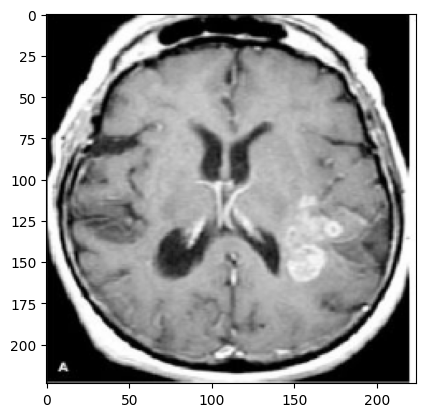

In [39]:
# Traçons une image.

def plot_image(image):
    plt.imshow(image)

plot_image(images[0])

Comme on peut le voir, nous avons stocké l'image et son étiquette respective dans des listes. Mais les étiquettes sont des chaînes de caractères qui ne peuvent pas être interprétées par des machines.

Il faut donc appliquer l'encodage One-hot aux étiquettes et normaliser les images et aussi convertir nos listes en tableaux numpy pour diviser davantage notre jeu de données.

In [40]:
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.utils import to_categorical
import numpy as np

In [41]:
images = np.array(images) / 255.0
labels = np.array(labels)

label_binarizer = LabelBinarizer()
labels = label_binarizer.fit_transform(labels)
labels = to_categorical(labels)

Avant de poursuivre, divisons notre dataset en train set et test set dans un rapport de 9-1 à l'aide de la fonction train_test_split() du package Scikit-learn.

In [42]:
from sklearn.model_selection import train_test_split

(X_train, X_test, y_train, y_test) = train_test_split(images, labels, test_size= 0.10, random_state= 42, stratify= labels)

### Étape 2 : Construction d'un modèle CNN

Avant de construire l'architecture de notre classificateur, nous devons comprendre ce qu'est un CNN.

Un réseau neuronal convolutif, ou Convolutional Neural Network (CNN en abrégé), est un réseau neuronal profond largement utilisé pour l'analyse des images visuelles. Ces types de réseaux fonctionnent bien pour des tâches comme la classification et la détection d'images, la segmentation d'images. Un CNN se compose de deux parties principales :

* Une couche convolutive qui fait le travail d'extraction des caractéristiques.
* Une couche entièrement connectée à la fin qui utilise la sortie des couches convolutionnelles et prédit la classe de l'image.

TensorFlow fournit ImageDataGenerator qui est utilisé pour l'augmentation des données (Data Augmentation). L'augmentation des données est extrêmement utile dans les cas où les données d'entrée sont très limitées. Nous utilisons donc différentes transformations pour augmenter la taille de l'ensemble de données. Il fournit diverses transformations comme la rotation, le retournement des images horizontalement, verticalement, le zoom, etc...

Nous utiliserons les transformations fill_mode et rotation_range pour remplir les pixels hors limites avec le pixel "le plus proche" d'eux et inclure une rotation de 15 degrés aux images.

In [43]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [44]:
train_generator = ImageDataGenerator(fill_mode= 'nearest', rotation_range= 15)

Comme la taille du dataset est très petite pour entraîner de tels réseaux neuronaux profonds, nous utiliserons la puissance du Transfer Learning pour faire les meilleures prédictions.

Le Transfer Learning consiste à exploiter les représentations des caractéristiques d'un modèle pré-entraîné, afin de ne pas avoir à former un nouveau modèle à partir de zéro.
Pour ce projet, nous utiliserons le modèle de réseau de pointe VGG16. Il existe un certain nombre de modèles pré-entraînés pouvant être utilisés dans Keras.(Voir l'architecture du modèle VGG16 sur internet).

In [45]:
# Nous supprimerons la dernière couche du réseau VGG16 et ajoutons des couches adaptées à notre problème.

from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.applications import VGG16

In [46]:
base_model = VGG16(weights= 'imagenet', input_tensor= Input(shape = (224, 224, 3)), include_top= False)
base_input = base_model.input

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [47]:
base_output = base_model.output
base_output = AveragePooling2D(pool_size=(4, 4))(base_output)
base_output = Flatten(name="flatten")(base_output)
base_output = Dense(64, activation="relu")(base_output)
base_output = Dropout(0.5)(base_output)
base_output = Dense(2, activation="softmax")(base_output)

En gélant les couches de notre modèle, le réseau n'est pas formé dès le début. Il utilisera les poids des couches précédentes et poursuivra la formation pour les couches que nous avons ajoutées par-dessus ces couches. Cela réduit considérablement le temps de formation.

In [48]:
for layer in base_model.layers:
    layer.trainable = False

Maintenant, construisons le modèle et compilons-le en utilisant Adam comme optimiseur avec un taux d'apprentissage de 0,001 et la précision comme métrique. Comme nous construisons un classificateur binaire et que l'entrée est une image, l'entropie croisée binaire est utilisée comme fonction de perte.

In [49]:
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [50]:
model = Model(inputs = base_input, outputs = base_output)
model.compile(optimizer= Adam(learning_rate= 1e-3), metrics= ['accuracy'], loss= 'binary_crossentropy')

In [51]:
# Voyons l'architecture de notre modèle:

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 1, 512)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 14,747,650 (56.26 MB)

 Trainable params: 32,962 (128.76 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Étape 3 : Entraînement et évaluation du modèle

Avant de commencer l'entraînement de notre modèle, enregistrons les hyperparamètres suivants.
Le modèle sera entraîné sur 10 époques (itérations complètes) avec train_steps pour l'ensemble d'entraînement et validation_steps pour l'ensemble de validation dans chaque époque. La taille du lot pour chaque époque est de 8.

In [52]:
batch_size = 8
train_steps = len(X_train) // batch_size
validation_steps = len(X_test) // batch_size
epochs = 10

In [ ]:
history = model.fit(train_generator.flow(X_train, y_train, batch_size= batch_size),
                                                   steps_per_epoch= train_steps,
                                                   validation_data = (X_test, y_test),
                                                   validation_steps= validation_steps,
                                                   epochs= epochs)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 140s 5s/step - accuracy: 0.5753 - loss: 0.7545 - val_accuracy: 0.6154 - val_loss: 0.6702
Epoch 2/10
 1/28 ━━━━━━━━━━━━━━━━━━━━ 2:30 6s/step - accuracy: 0.8750 - loss: 0.5325

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 497ms/step - accuracy: 0.8750 - loss: 0.5325 - val_accuracy: 0.5769 - val_loss: 0.6722
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 133s 5s/step - accuracy: 0.6393 - loss: 0.6569 - val_accuracy: 0.6538 - val_loss: 0.6233
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 25s 760ms/step - accuracy: 0.3750 - loss: 0.7819 - val_accuracy: 0.6538 - val_loss: 0.6230
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 139s 5s/step - accuracy: 0.6895 - loss: 0.6091 - val_accuracy: 0.6538 - val_loss: 0.6037
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 24s 759ms/step - accuracy: 0.7500 - loss: 0.5246 - val_accuracy: 0.6538 - val_loss: 0.6034
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 139s 5s/step - accuracy: 0.7123 - loss: 0.5917 - val_accuracy: 0.7692 - val_loss: 0.5856
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 521ms/step - accuracy: 0.7500 - loss: 0.5923 - val_accuracy: 0.7692 - val_loss: 0.5845
Epoch 9/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 140s 5s/step - accuracy: 0.7489 - loss: 0.5237 - val_accuracy: 0.7308 - val_

Notre modèle a obtenu une précision de 96,15 % sur l'ensemble de test.

Évaluons maintenant notre modèle à l'aide de la fonction predict().

In [53]:
from sklearn.metrics import classification_report, confusion_matrix

In [55]:
predictions = model.predict(X_test, batch_size= batch_size)
predictions = np.argmax(predictions, axis= 1)
actuals = np.argmax(y_test, axis= 1)

print(classification_report(actuals, predictions, target_names= label_binarizer.classes_))


cm = confusion_matrix(actuals, predictions)
print(cm)

4/4 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step
              precision    recall  f1-score   support

          no       0.38      1.00      0.56        10
         yes       0.00      0.00      0.00        16

    accuracy                           0.38        26
   macro avg       0.19      0.50      0.28        26
weighted avg       0.15      0.38      0.21        26

[[10  0]
 [16  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Les prédictions faites par le modèle seront un tableau dont chaque valeur représente la probabilité que l'image appartienne à cette catégorie. Nous prenons donc le maximum de toutes ces probabilités et attribuons l'étiquette prédite à cette entrée d'image.

Une matrice de confusion est une représentation matricielle montrant comment le modèle entraîné prédit chaque classe cible par rapport aux comptes. Elle contient 4 valeurs dans le format suivant :

    TP FN
    FP TN

* Vrai positif (TP) : La cible est positive et le modèle l'a prédite comme positive.
* Faux négatif (FN) : La cible est positive et le modèle l'a prédite comme négative.
* Faux positif (FP) : La cible est négative et le modèle l'a prédite comme positive.
* Vrai négatif (TN) : La cible est négative et le modèle l'a prédite comme négative.

Le rapport de classification fournit un résumé des mesures de précision, de rappel et de score F1 pour chaque classe/étiquette de l'ensemble de données. Il fournit également la précision et le nombre d'échantillons de données de chaque étiquette catégorisée.


### Précision globale du modèle.

Trouvons maintenant la précision globale du modèle en utilisant la formule : (TP + TN) / (TP + FN + FN + TN)

In [57]:
total = sum(sum(cm))
accuracy = (cm[0, 0] + cm[1, 1]) / total
print("La précision globale de notre modèle est de: {:.4f}".format(accuracy))

La précision globale de notre modèle est de: 0.3846


In [58]:
# Tracons les métriques en utilisant matplotlib

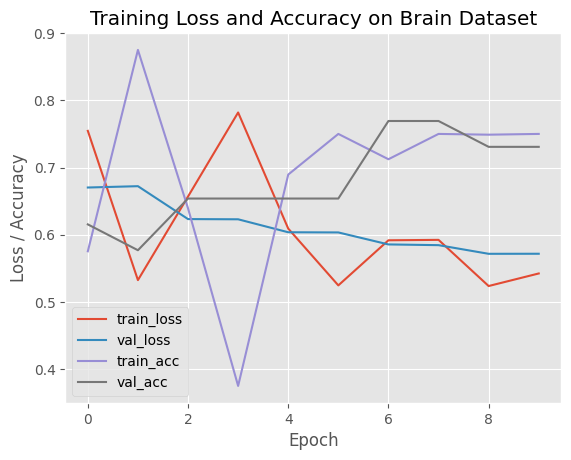

In [ ]:
N = epochs
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), history.history["loss"], label= "train_loss")
plt.plot(np.arange(0, N), history.history["val_loss"], label= "val_loss")

plt.plot(np.arange(0, N), history.history["accuracy"], label= "train_acc")
plt.plot(np.arange(0, N), history.history["val_accuracy"], label= "val_acc")

plt.title("Training Loss and Accuracy on Brain Dataset")
plt.xlabel("Epoch")
plt.ylabel("Loss / Accuracy")
plt.legend(loc= "lower left")
plt.savefig("Training Loss and Accuracy on Brain Dataset.jpg")

Dans le cadre de la classification des tumeurs cérébrales par apprentissage automatique, nous avons construit un classificateur binaire pour détecter les tumeurs cérébrales à partir d'images IRM.
Nous avons construit notre classificateur en utilisant transfer learning et avons obtenu une précision de 96,15 % et visualisé la performance globale de notre modèle.